In [ ]:
#| default_exp Home

![Python Package](https://img.shields.io/badge/python-3.10%20%7C%203.11%20%7C%203.12%20%7C%203.13-blue)

# peshbeen

**peshbeen** is a easy-to-use Python library designed for time series forecasting. It provides a simple and intuitive interface for building, training, and evaluating forecasting models. It automatically handles data preprocessing specific to time series data, making it easier for users to focus on model development and evaluation. Peshbeen supports a variety of forecasting models, including traditional statistical models and modern machine learning approaches, including Linear Regression, Random Forest, XGBoost, LightGBM, CatBoost, and Cubist.

## Why peshbeen

- **Automated Detrending Engine**: Seamlessly handles non-stationary data using global linear trends, piecewise linear regression (for structural breaks), or ETS (Exponential Smoothing) to capture evolving trend dynamics.

- **Broad Model Support:** Out-of-the-box compatibility with the leading tree-based and boosting architectures, including XGBoost, LightGBM, CatBoost, Random Forest, and AdaBoost.

- **Intelligent Optimization:** Leverages Bayesian Optimization (Hyperopt) to not only tune machine learning hyperparameters but also to optimize smoothing parameters for ETS detrending.

- **Uncertainty Quantification:** Goes beyond simple point forecasts with a suite of probabilistic approaches:

    - **Empirical Distributions:** Leveraged via boosting.

    - **KDE (Kernel Density Estimation):** For non-parametric forecast distribution modeling.

    - **Correlated Error Modeling:** Accounting for error dependencies across the forecast horizon.

    - **Conformal Prediction:** Distribution-free uncertainty estimates.


In [ ]:
#| hide
from peshbeen.metrics import RMSE, MAE
print(MAE([3, -0.5, 2, 7], [2.5, 0.0, 2, 8]))

0.5


In [ ]:
from peshbeen.datasets import load_wales_admissions
# split the data into train and test sets
train = load_wales_admissions[:-30]
test = load_wales_admissions[-30:]

In [ ]:
from peshbeen.models import ml_forecaster

/Users/aslanm/Desktop/my_desk/peshbeen/.venv/lib/python3.13/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
# import linear regression from sklearn
from sklearn.linear_model import LinearRegression
ml_linear = ml_forecaster(model=LinearRegression(),
              target_col='admissions', lags = 7)

In [ ]:
ml_linear.fit(train)

In [ ]:
ml_linear.forecast(H=30)

array([8837.64012317, 8809.61409562, 8800.56549201, 8808.3564168 ,
       8831.16805604, 8837.29675557, 8834.15615162, 8824.03294077,
       8813.03281712, 8805.24801163, 8805.10516068, 8807.59985417,
       8809.44916909, 8808.68920192, 8805.40625265, 8800.62432546,
       8796.6095056 , 8794.15334057, 8792.93850576, 8792.08382984,
       8790.84528641, 8788.81540179, 8786.25136535, 8783.64463352,
       8781.3601215 , 8779.47089754, 8777.8324959 , 8776.19551565,
       8774.39826787, 8772.43408096])

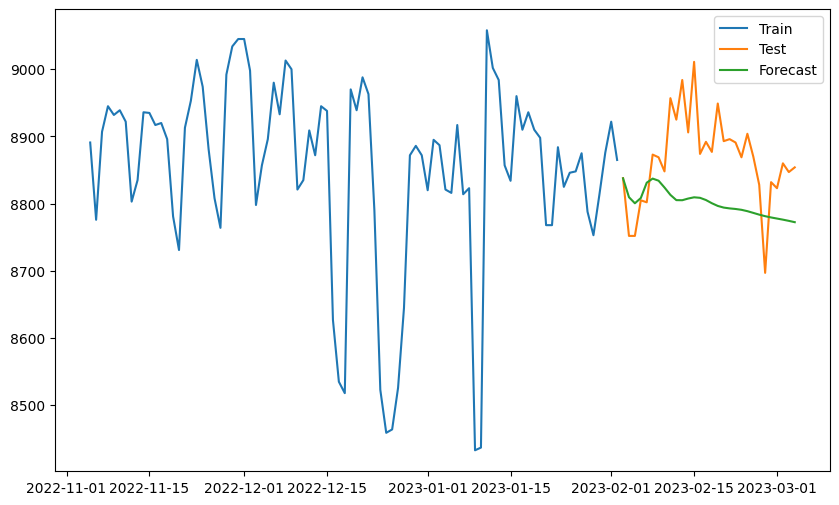

In [ ]:
# plot the forecast against the actual values
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train.index[-90:], train['admissions'][-90:], label='Train')
plt.plot(test.index, test['admissions'], label='Test')
plt.plot(test.index, ml_linear.forecast(H=30), label='Forecast')
plt.legend()
plt.show()